<a href="https://colab.research.google.com/github/enslern/The-AI-engineer-course-2026-Complete-AI-bootcamp/blob/main/Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TEXTBLOB

In [48]:
from textblob import TextBlob

In [49]:
sentence_1 = "i had a great time at the movie it was really funny"
sentence_2 = "i had a great time at the movie but the parking was terrible"
sentence_3 = "i had a great time at the movie but the parking wasn't great"
sentence_4 = "i went to see a movie"

In [50]:
sentiment_score1=TextBlob(sentence_1)
sentiment_score2=TextBlob(sentence_2)
sentiment_score3=TextBlob(sentence_3)
sentiment_score4=TextBlob(sentence_4)
print(f"{sentence_1}:{sentiment_score1.sentiment.polarity}")
print(f"{sentence_2}:{sentiment_score2.sentiment.polarity}")
print(f"{sentence_3}:{sentiment_score3.sentiment.polarity}")
print(f"{sentence_4}:{sentiment_score4.sentiment.polarity}")


i had a great time at the movie it was really funny:0.525
i had a great time at the movie but the parking was terrible:-0.09999999999999998
i had a great time at the movie but the parking wasn't great:0.8
i went to see a movie:0.0


VADER

In [51]:
!pip install vaderSentiment

In [52]:
import vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [53]:
print(sentence_1)
vader_sentiment=SentimentIntensityAnalyzer()
print(vader_sentiment.polarity_scores(sentence_1))

i had a great time at the movie it was really funny
{'neg': 0.0, 'neu': 0.578, 'pos': 0.422, 'compound': 0.807}


PRE-TRAINED TRANSFORMERS

In [54]:
import transformers
from transformers import pipeline

In [55]:
sentiment_analysis=pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [56]:
print(sentence_1)
print(sentiment_analysis(sentence_1))

i had a great time at the movie it was really funny
[{'label': 'POSITIVE', 'score': 0.9998176693916321}]


EXERCISE 3:SENTIMENT ANALYSIS

In [57]:
!pip install vaderSentiment

In [58]:
import pandas as pd
import numpy as np
from  vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline
import re

In [59]:
data=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/resources/book_reviews_sample.csv")

In [60]:
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [61]:
pattern=r"[^\w\s]"
data["no_punct"]=data["reviewText"].apply(lambda x:re.sub(pattern," ",x))

In [62]:
data.head()

,index,reviewText,rating,no_punct
0,11494,Clean and funny. A bit busy with all the diffe...,3,Clean and funny A bit busy with all the diffe...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,Alex a sexy hot cop and the PhD candidate Wha...
2,1463,Good thing that this is a free story. I read i...,1,Good thing that this is a free story I read i...
3,10342,"Action, action, action! Equipment keeps gettin...",4,Action action action Equipment keeps gettin...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [63]:
vader_sentiment=SentimentIntensityAnalyzer()
data["vader_sentiment_score"]=data["no_punct"].apply(lambda x: vader_sentiment.polarity_scores(x)["compound"])
data.head()

,index,reviewText,rating,no_punct,vader_sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,Clean and funny A bit busy with all the diffe...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,Alex a sexy hot cop and the PhD candidate Wha...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,Good thing that this is a free story I read i...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,Action action action Equipment keeps gettin...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [65]:
bins=[-1,-0.1,0.1,1]
names=["negative","neutral","positive"]
data["vader_sentiment_label"]=pd.cut(data["vader_sentiment_score"],bins,labels=names)

In [66]:
data.head()

,index,reviewText,rating,no_punct,vader_sentiment_score,vader_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,Clean and funny A bit busy with all the diffe...,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,Alex a sexy hot cop and the PhD candidate Wha...,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,Good thing that this is a free story I read i...,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,Action action action Equipment keeps gettin...,0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative


<Axes: xlabel='vader_sentiment_label'>

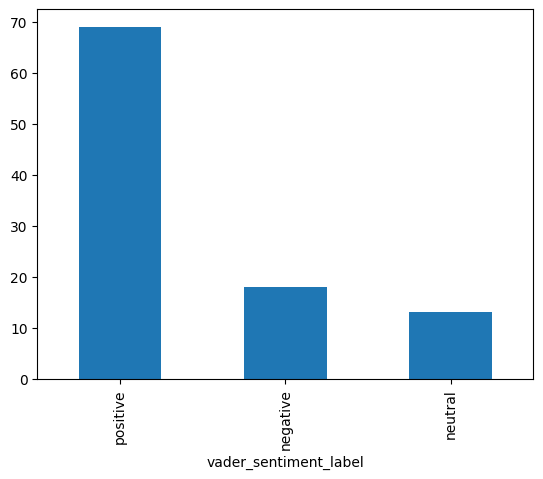

In [67]:
data['vader_sentiment_label'].value_counts().plot.bar()

In [68]:
sentiment_analysis=pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [73]:
data["transformer_senetiment_score"]=data["no_punct"].apply(lambda x:sentiment_analysis(x)[0]["score"])

In [74]:
data.head()

,index,reviewText,rating,no_punct,vader_sentiment_score,vader_sentiment_label,transformer_senetiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,Clean and funny A bit busy with all the diffe...,0.7684,positive,0.998570
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,Alex a sexy hot cop and the PhD candidate Wha...,0.9325,positive,0.999864
2,1463,Good thing that this is a free story. I read i...,1,Good thing that this is a free story I read i...,0.6740,positive,0.999733
3,10342,"Action, action, action! Equipment keeps gettin...",4,Action action action Equipment keeps gettin...,0.6652,positive,0.757572
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative,0.999435


<Axes: xlabel='transformer_label'>

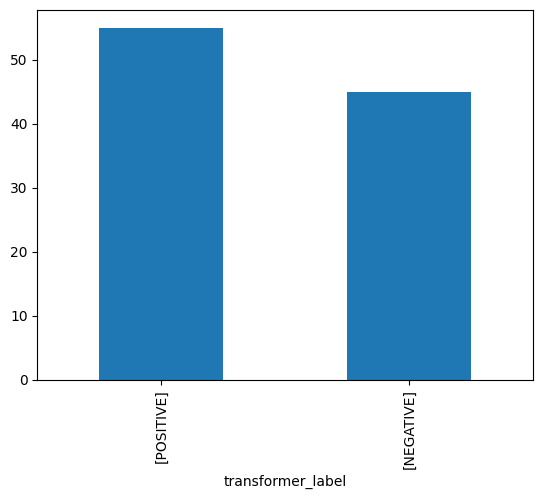

In [75]:
transformer_label=[]
for review in data["no_punct"]:
  sentiment_list=sentiment_analysis(review)
  sentiment_label=[sent["label"] for sent in sentiment_list]
  transformer_label.append(sentiment_label)
data["transformer_label"]=transformer_label
data["transformer_label"].value_counts().plot.bar()

In [77]:
data.head()

,index,reviewText,rating,no_punct,vader_sentiment_score,vader_sentiment_label,transformer_senetiment_score,transformer_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,Clean and funny A bit busy with all the diffe...,0.7684,positive,0.998570,[POSITIVE]
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,Alex a sexy hot cop and the PhD candidate Wha...,0.9325,positive,0.999864,[POSITIVE]
2,1463,Good thing that this is a free story. I read i...,1,Good thing that this is a free story I read i...,0.6740,positive,0.999733,[NEGATIVE]
3,10342,"Action, action, action! Equipment keeps gettin...",4,Action action action Equipment keeps gettin...,0.6652,positive,0.757572,[NEGATIVE]
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative,0.999435,[NEGATIVE]
